# E-Commerce Return Fraud Detection
## InternVL2.5-4B MPO + LoRA â€” Multimodal Return Validation

**Pipeline:**
```
4 Delivery Images + 4 Vendor Images + Metadata
              â†“
    InternVL2.5-4B MPO (fine-tuned with LoRA)
              â†“
  Strict JSON: product_match, design_match, color_match,
               quantity_is_one, is_damaged, is_used
              â†“
    Logic Gate â†’ accept_return: yes/no
```

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
!pip install torch transformers peft pillow scikit-learn matplotlib seaborn accelerate --quiet
print('Setup complete')

Setup complete


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\shant\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## 1. Test Cases & Placeholder Images

In [2]:
from data.test_cases import TEST_CASES, create_placeholder_image
import pandas as pd

create_placeholder_image()

df = pd.DataFrame([{
    'id':          c['id'],
    'description': c['description'],
    'product':     c['metadata']['product'],
    'expected':    c['ground_truth']['accept_return'],
} for c in TEST_CASES])
print(df.to_string(index=False))

[Data] Placeholder image created: F:\AI_projects\bayer-ai-hackathon\fraud_detection_ecommerce\data\placeholder.jpg
   id                            description            product expected
TC001 Valid return â€” correct product, unused  Blue Denim Jacket      yes
TC002     Fraud â€” different product returned     Red Silk Saree       no
TC003            Reject â€” product is damaged Ceramic Coffee Mug       no
TC004               Reject â€” product is used      Running Shoes       no
TC005                Reject â€” color mismatch       Cotton Kurta       no
TC006         Reject â€” quantity > 1 returned   Wireless Earbuds       no


## 2. Validation Logic â€” accept_return Rules

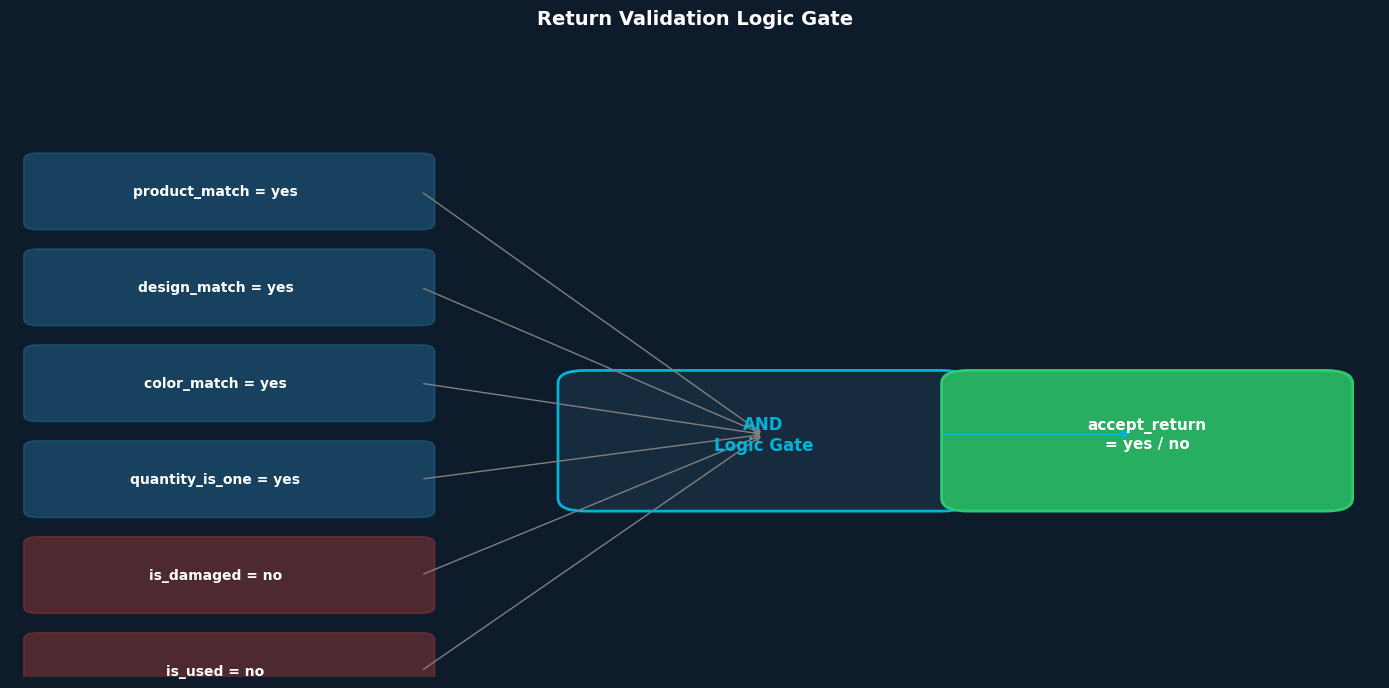

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#0d1b2a')

fields = [
    ('product_match = yes',   0.15, 0.75, '#3498db'),
    ('design_match = yes',    0.15, 0.60, '#3498db'),
    ('color_match = yes',     0.15, 0.45, '#3498db'),
    ('quantity_is_one = yes', 0.15, 0.30, '#3498db'),
    ('is_damaged = no',       0.15, 0.15, '#e74c3c'),
    ('is_used = no',          0.15, 0.00, '#e74c3c'),
]

for label, x, y, color in fields:
    ax.add_patch(mpatches.FancyBboxPatch((x-0.13, y-0.04), 0.28, 0.10,
        boxstyle='round,pad=0.01', facecolor=color, alpha=0.3, edgecolor=color))
    ax.text(x, y+0.01, label, ha='center', va='center',
            color='white', fontsize=10, fontweight='bold')
    ax.annotate('', xy=(0.55, 0.38), xytext=(x+0.15, y+0.01),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax.add_patch(mpatches.FancyBboxPatch((0.42, 0.28), 0.26, 0.18,
    boxstyle='round,pad=0.02', facecolor='#162b3e', edgecolor='#00b4d8', linewidth=2))
ax.text(0.55, 0.38, 'AND\nLogic Gate', ha='center', va='center',
        color='#00b4d8', fontsize=12, fontweight='bold')

ax.annotate('', xy=(0.82, 0.38), xytext=(0.68, 0.38),
            arrowprops=dict(arrowstyle='->', color='#00b4d8', lw=2))

ax.add_patch(mpatches.FancyBboxPatch((0.70, 0.28), 0.26, 0.18,
    boxstyle='round,pad=0.02', facecolor='#27ae60', edgecolor='#2ecc71', linewidth=2))
ax.text(0.83, 0.38, 'accept_return\n= yes / no', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold')

ax.set_title('Return Validation Logic Gate', color='white', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('validation_logic.png', dpi=130, bbox_inches='tight', facecolor='#0d1b2a')
plt.show()

## 3. Mock Predictions (No GPU Required)

In [4]:
import json

# Simulate model predictions â€” replace with real model output
# To use real model: from model.internvl_lora import ReturnValidator
mock_predictions = [
    # TC001 â€” correct
    {'product_match':'yes','design_match':'yes','color_match':'yes',
     'quantity_is_one':'yes','is_damaged':'no','is_used':'no','accept_return':'yes'},
    # TC002 â€” fraud detected
    {'product_match':'no','design_match':'no','color_match':'no',
     'quantity_is_one':'yes','is_damaged':'no','is_used':'no','accept_return':'no'},
    # TC003 â€” damaged
    {'product_match':'yes','design_match':'yes','color_match':'yes',
     'quantity_is_one':'yes','is_damaged':'yes','is_used':'no','accept_return':'no'},
    # TC004 â€” used
    {'product_match':'yes','design_match':'yes','color_match':'yes',
     'quantity_is_one':'yes','is_damaged':'no','is_used':'yes','accept_return':'no'},
    # TC005 â€” color mismatch
    {'product_match':'yes','design_match':'yes','color_match':'no',
     'quantity_is_one':'yes','is_damaged':'no','is_used':'no','accept_return':'no'},
    # TC006 â€” quantity fraud (hallucination example: model says accept despite qty=no)
    {'product_match':'yes','design_match':'yes','color_match':'yes',
     'quantity_is_one':'no','is_damaged':'no','is_used':'no','accept_return':'yes'},  # hallucination!
]

ground_truths = [c['ground_truth'] for c in TEST_CASES]

print('Predictions loaded. TC006 has a hallucination (accept=yes despite qty=no)')

Predictions loaded. TC006 has a hallucination (accept=yes despite qty=no)


## 4. Per-Field Metrics (F1, Precision, Recall)

                 accuracy  precision  recall      f1
field                                               
product_match      1.0000        1.0     1.0  1.0000
design_match       1.0000        1.0     1.0  1.0000
color_match        1.0000        1.0     1.0  1.0000
quantity_is_one    1.0000        1.0     1.0  1.0000
is_damaged         1.0000        1.0     1.0  1.0000
is_used            1.0000        1.0     1.0  1.0000
accept_return      0.8333        0.5     1.0  0.6667


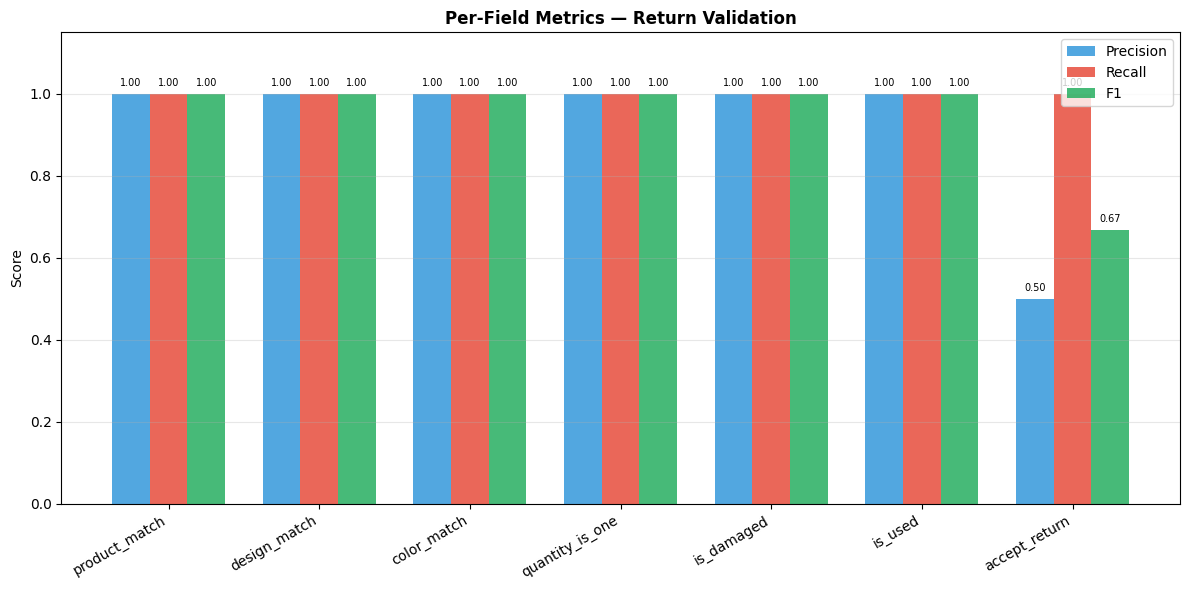

In [5]:
from evaluation.metrics import compute_field_metrics, plot_field_metrics

field_df = compute_field_metrics(mock_predictions, ground_truths)
print(field_df.to_string())
plot_field_metrics(field_df, save_path='field_metrics.png')

## 5. Fraud Detection Metrics (accept_return)

  accuracy                 : 0.8333
  f1                       : 0.6667
  precision                : 0.5
  recall                   : 1.0
  true_positives           : 1
  true_negatives           : 4
  false_positives          : 1
  false_negatives          : 0
  fraud_slip_rate          : 0.0


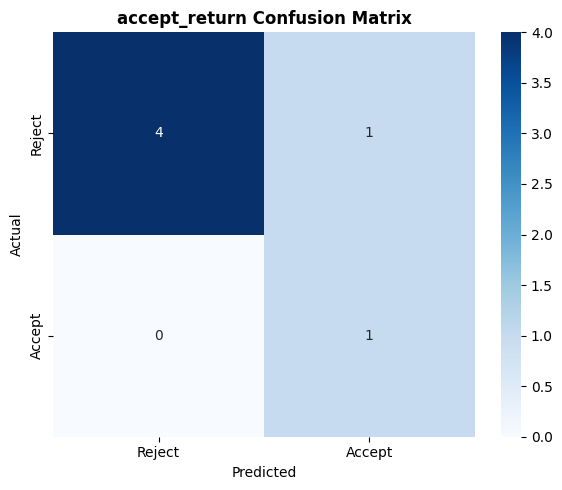

In [6]:
from evaluation.metrics import compute_fraud_detection_metrics, plot_confusion_matrix

fraud = compute_fraud_detection_metrics(mock_predictions, ground_truths)
for k, v in fraud.items():
    if not isinstance(v, list):
        print(f'  {k:<25}: {v}')

plot_confusion_matrix(mock_predictions, ground_truths, save_path='confusion_matrix.png')

## 6. Hallucination Detection

In [7]:
from evaluation.metrics import compute_hallucination_score

hall = compute_hallucination_score(mock_predictions)
print(f'Hallucination Rate : {hall["hallucination_rate"]:.2%}')
print(f'Consistency Score  : {hall["consistency_score"]:.2%}')
print(f'Logic Errors       : {hall["hallucinated"]} / {hall["total_cases"]}')
print()
for err in hall['logic_errors']:
    print(f'  Case {err["index"]+1}: model said accept={err["model_accept"]} but logic says {err["logical_accept"]}')
    print(f'  Fields: {err["fields"]}')

Hallucination Rate : 16.67%
Consistency Score  : 83.33%
Logic Errors       : 1 / 6

  Case 6: model said accept=yes but logic says no
  Fields: {'product_match': 'yes', 'design_match': 'yes', 'color_match': 'yes', 'quantity_is_one': 'no', 'is_damaged': 'no', 'is_used': 'no', 'accept_return': 'yes'}


## 7. Hallucination Visualization

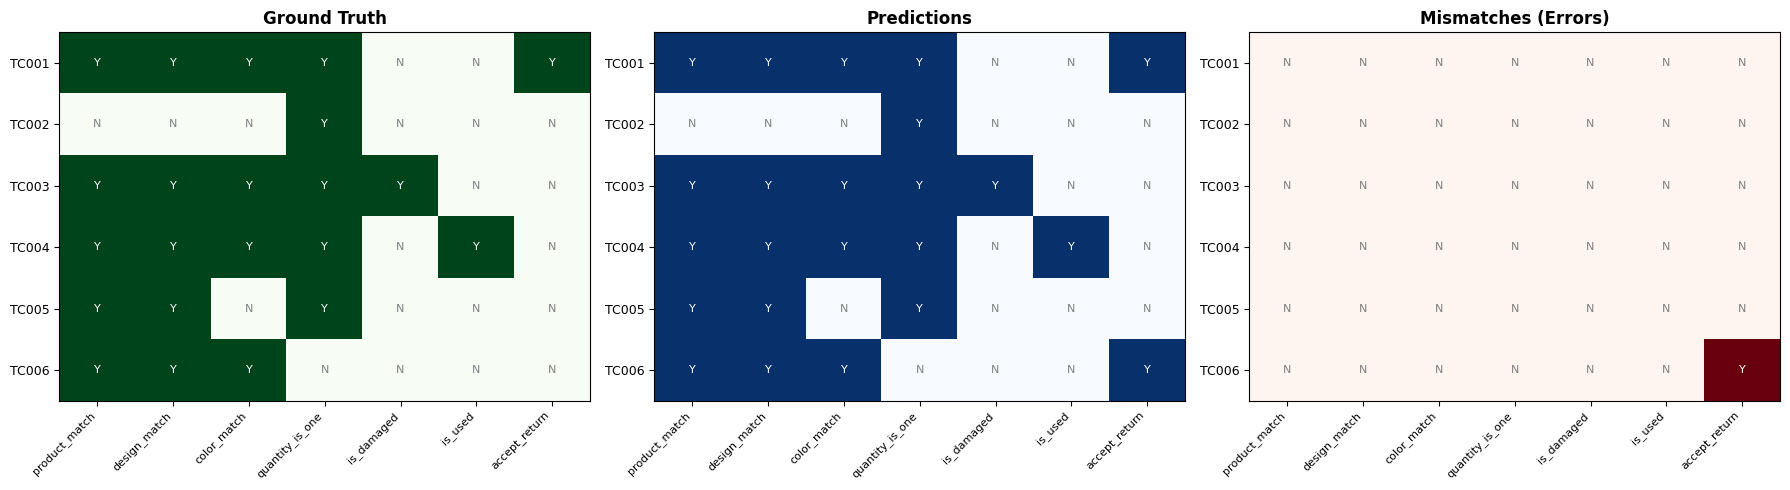

TC006 column 6 (accept_return) shows RED = hallucination


In [8]:
import matplotlib.pyplot as plt
import numpy as np

fields = ['product_match','design_match','color_match','quantity_is_one','is_damaged','is_used','accept_return']
case_ids = [c['id'] for c in TEST_CASES]

# Build heatmap: 1=yes, 0=no
pred_matrix = np.array([[1 if p.get(f,'no')=='yes' else 0 for f in fields] for p in mock_predictions])
gt_matrix   = np.array([[1 if g.get(f,'no')=='yes' else 0 for f in fields] for g in ground_truths])
diff_matrix = (pred_matrix != gt_matrix).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Ground Truth', 'Predictions', 'Mismatches (Errors)']
matrices = [gt_matrix, pred_matrix, diff_matrix]
cmaps = ['Greens', 'Blues', 'Reds']

for ax, mat, title, cmap in zip(axes, matrices, titles, cmaps):
    sns_data = mat
    im = ax.imshow(sns_data, cmap=cmap, aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(fields)))
    ax.set_xticklabels(fields, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(case_ids)))
    ax.set_yticklabels(case_ids, fontsize=9)
    ax.set_title(title, fontweight='bold')
    for i in range(len(case_ids)):
        for j in range(len(fields)):
            ax.text(j, i, 'Y' if mat[i,j]==1 else 'N',
                    ha='center', va='center', fontsize=8,
                    color='white' if mat[i,j]==1 else 'gray')

plt.tight_layout()
plt.savefig('hallucination_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('TC006 column 6 (accept_return) shows RED = hallucination')

## 8. Full Report

In [9]:
from evaluation.metrics import full_report
report = full_report(mock_predictions, ground_truths)


  RETURN VALIDATION â€” FULL EVALUATION REPORT

Per-Field Metrics:
                 accuracy  precision  recall      f1
field                                               
product_match      1.0000        1.0     1.0  1.0000
design_match       1.0000        1.0     1.0  1.0000
color_match        1.0000        1.0     1.0  1.0000
quantity_is_one    1.0000        1.0     1.0  1.0000
is_damaged         1.0000        1.0     1.0  1.0000
is_used            1.0000        1.0     1.0  1.0000
accept_return      0.8333        0.5     1.0  0.6667

Fraud Detection (accept_return):
  accuracy                 : 0.8333
  f1                       : 0.6667
  precision                : 0.5
  recall                   : 1.0
  true_positives           : 1
  true_negatives           : 4
  false_positives          : 1
  false_negatives          : 0
  fraud_slip_rate          : 0.0

Hallucination Analysis:
  Hallucination Rate : 16.67%
  Consistency Score  : 83.33%
  Logic Errors       : 1 / 6


## 9. Real Model Inference (requires GPU + model weights)

In [10]:
# Uncomment to run with real model
# from model.internvl_lora import ReturnValidator
#
# validator = ReturnValidator(use_lora=True, load_in_4bit=True)
# result = validator.validate(
#     delivery_images=['path/to/delivery1.jpg', ...],  # 4 images
#     vendor_images  =['path/to/vendor1.jpg',   ...],  # 4 images
#     metadata={
#         'product':  'Blue Denim Jacket',
#         'brand':    "Levi's",
#         'color':    'blue',
#         'design':   'plain denim',
#         'quantity': '1',
#     }
# )
# result = validator.validate_accept_return(result)
# print(result)
print('Uncomment above to run real inference')

Uncomment above to run real inference
